In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


=== [선택된 비침습적 예측 피처 리스트] ===
1. Pregnancies
2. BloodPressure
3. SkinThickness
4. BMI
5. DiabetesPedigreeFunction
6. Age
7. BMI_Age_Product
8. Pregnancies_Age_Ratio

>>> [비침습 모델] XGBoost 과적합 차단 규제 튜닝 시작...
>>> [비침습 모델] LightGBM 과적합 차단 규제 튜닝 시작...

       [채혈 없는 비침습적(Non-Invasive) 모델 최종 결과]       
[XGBoost Non-Invasive]
  - Train Set AUC : 0.8142
  - Test Set AUC  : 0.7793
  - AUC 격차(Gap) : 0.0348 ☞ [안정] 격차 5% 이내로 우수한 일반화 성능 확인.
  - Accuracy      : 0.7013
  - Precision     : 0.6200
  - Recall        : 0.3827 (민감도: 실제 환자를 찾아낸 비율)
  - F1-Score      : 0.4733
------------------------------------------------------------
[LightGBM Non-Invasive]
  - Train Set AUC : 0.8219
  - Test Set AUC  : 0.7761
  - AUC 격차(Gap) : 0.0458 ☞ [안정] 격차 5% 이내로 우수한 일반화 성능 확인.
  - Accuracy      : 0.6926
  - Precision     : 0.5833
  - Recall        : 0.4321 (민감도: 실제 환자를 찾아낸 비율)
  - F1-Score      : 0.4965
------------------------------------------------------------


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


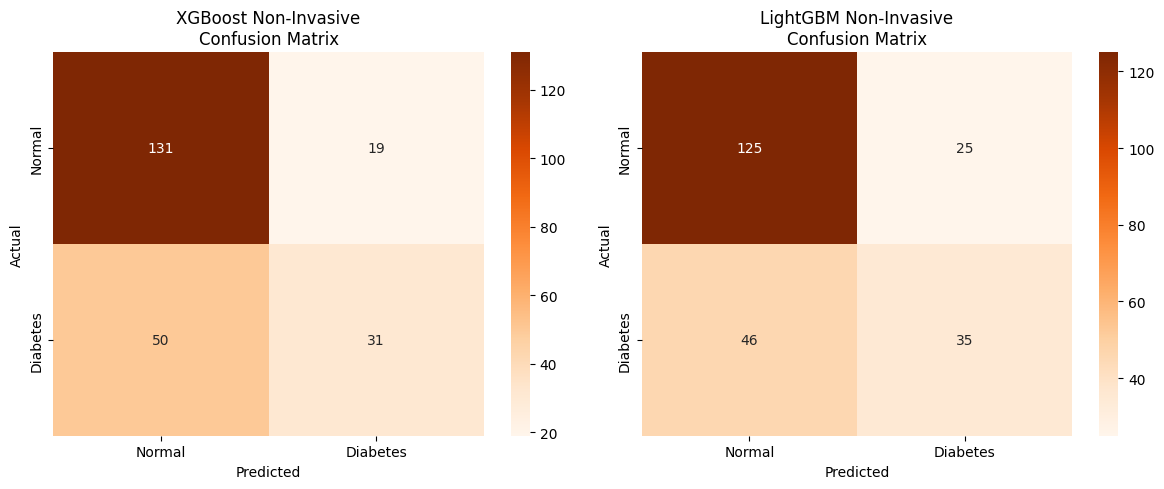

In [2]:
# =========================================================================
# [1단계]필수 라이브러리 로드
# =========================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
import lightgbm as lgb

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix
)

# =========================================================================
# [2단계] 데이터 로드 및 '비침습' 피처 선택 (Glucose, Insulin 제외)
# =========================================================================
file_path = '/content/drive/MyDrive/AIAP/diabetes.csv'
df = pd.read_csv(file_path)

# ★ 핵심 조치: 채혈이 필요한 Glucose와 Insulin 피처를 데이터프레임에서 완전히 삭제합니다.
# 또한 기존 final2에 있던 Glucose 기반 파생 변수들도 모두 사용할 수 없으므로 제외합니다.
df_non_invasive = df.drop(['Glucose', 'Insulin'], axis=1)

# 의학적으로 0이 될 수 없는 남은 신체 지표들을 결측치 처리 대상 지정
zero_features = ['BloodPressure', 'SkinThickness', 'BMI']
df_non_invasive[zero_features] = df_non_invasive[zero_features].replace(0, np.nan)

# 결측치를 각 피처의 중앙값(Median)으로 정밀 대체
for feature in zero_features:
    median_val = df_non_invasive[feature].median()
    df_non_invasive[feature] = df_non_invasive[feature].fillna(median_val)

# =========================================================================
# [3단계] 비침습적 데이터 전용 파생 변수 생성 (도메인 기반)
# =========================================================================
# 1. 대사증후군 및 비만 가중치 지표 (체질량지수와 나이의 복합 작용)
df_non_invasive['BMI_Age_Product'] = df_non_invasive['BMI'] * df_non_invasive['Age']

# 2. 임신 횟수 대비 연령 비율 (출산력과 노화의 복합 관계)
df_non_invasive['Pregnancies_Age_Ratio'] = df_non_invasive['Pregnancies'] / (df_non_invasive['Age'] + 1e-5)

# =========================================================================
# [4단계] 데이터 분할 및 표준화 스케일링
# =========================================================================
X = df_non_invasive.drop('Outcome', axis=1)
y = df_non_invasive['Outcome']

# 훈련 데이터와 테스트 데이터 분할 (7:3 비율, stratify 적용)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# 표준화 스케일링 적용
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 사용된 비침습 피처 확인 출력
print("=== [선택된 비침습적 예측 피처 리스트] ===")
for i, col in enumerate(X.columns):
    print(f"{i+1}. {col}")
print("=========================================\n")

# =========================================================================
# [5단계] XGBoost 비침습 특화형 과적합 차단 학습
# =========================================================================
print(">>> [비침습 모델] XGBoost 과적합 차단 규제 튜닝 시작...")

xgb_strict_grid = {
    'max_depth': [2, 3],                # 깊이 제한으로 데이터를 외우는 현상 차단
    'learning_rate': [0.01, 0.03],      # 완만하게 최적점을 찾아가도록 설정
    'subsample': [0.6, 0.7],            # 데이터의 일부만 사용하여 나무의 다양성 확보
    'colsample_bytree': [0.6, 0.7],     # 피처 무작위 추출 비율 제한
    'reg_alpha': [0.5, 1.0, 2.0],       # L1 규제 적용
    'reg_lambda': [2.0, 5.0, 10.0],     # L2 규제 극대화로 가중치 억제
    'n_estimators': [100, 150]
}

base_xgb = xgb.XGBClassifier(random_state=42, eval_metric='logloss')
grid_xgb = GridSearchCV(estimator=base_xgb, param_grid=xgb_strict_grid, cv=5, scoring='roc_auc', n_jobs=-1)
grid_xgb.fit(X_train_scaled, y_train)

best_xgb = grid_xgb.best_estimator_

# =========================================================================
# [6단계] LightGBM 비침습 특화형 과적합 차단 학습
# =========================================================================
print(">>> [비침습 모델] LightGBM 과적합 차단 규제 튜닝 시작...")

lgb_strict_grid = {
    'max_depth': [2, 3],
    'num_leaves': [3, 5, 7],            # 리프 노드 개수를 제어하여 비대 성장 억제
    'min_child_samples': [30, 40, 50],  # 말단 노드의 최소 데이터 기준을 높여 잔가지 차단
    'learning_rate': [0.01, 0.03],
    'subsample': [0.6, 0.7],
    'reg_alpha': [0.5, 1.0, 2.0],
    'reg_lambda': [2.0, 5.0, 10.0],
    'n_estimators': [100, 150]
}

base_lgb = lgb.LGBMClassifier(random_state=42, verbose=-1)
grid_lgb = GridSearchCV(estimator=base_lgb, param_grid=lgb_strict_grid, cv=5, scoring='roc_auc', n_jobs=-1)
grid_lgb.fit(X_train_scaled, y_train)

best_lgb = grid_lgb.best_estimator_

# =========================================================================
# [7단계] 최종 비침습 모델 과적합 제어 성능 평가
# =========================================================================
print("\n" + "="*60)
print("       [채혈 없는 비침습적(Non-Invasive) 모델 최종 결과]       ")
print("="*60)

models = [('XGBoost Non-Invasive', best_xgb), ('LightGBM Non-Invasive', best_lgb)]

for name, model in models:
    y_pred = model.predict(X_test_scaled)
    y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]

    train_auc = roc_auc_score(y_train, model.predict_proba(X_train_scaled)[:, 1])
    test_auc = roc_auc_score(y_test, y_pred_proba)
    auc_gap = train_auc - test_auc

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    print(f"[{name}]")
    print(f"  - Train Set AUC : {train_auc:.4f}")
    print(f"  - Test Set AUC  : {test_auc:.4f}")
    print(f"  - AUC 격차(Gap) : {auc_gap:.4f} ", end="")

    if auc_gap <= 0.03:
         print("☞ [성공] 훈련/테스트 격차 3% 이내로 과적합 완벽 차단!")
    elif auc_gap <= 0.05:
         print("☞ [안정] 격차 5% 이내로 우수한 일반화 성능 확인.")
    else:
         print("☞ [경고] 과적합 경향이 남아있습니다.")

    print(f"  - Accuracy      : {acc:.4f}")
    print(f"  - Precision     : {prec:.4f}")
    print(f"  - Recall        : {rec:.4f} (민감도: 실제 환자를 찾아낸 비율)")
    print(f"  - F1-Score      : {f1:.4f}")
    print("-" * 60)

# =========================================================================
# [8단계] 비침습 모델 오차행렬 시각화
# =========================================================================
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for i, (name, model) in enumerate(models):
    y_pred = model.predict(X_test_scaled)
    cm = confusion_matrix(y_test, y_pred)

    sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', ax=axes[i],
                xticklabels=['Normal', 'Diabetes'], yticklabels=['Normal', 'Diabetes'])
    axes[i].set_title(f'{name}\nConfusion Matrix')
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')

plt.tight_layout()
plt.show()